# Day 2 — The Art of Training: Tuning & Debugging

What separates a decent model from a great one isn't magic; it's **methodical tuning**.

Yesterday you trained a network and it... worked. But *why* did it work? Would a different learning
rate have been better? How would you even know? Today you will learn to:

1. Build a **reusable training function** that records the full history of training — the foundation
   for every experiment this week
2. **Read loss curves like a story**: underfitting, overfitting, and the sweet spot in between
3. Navigate **hyperparameter space**: learning rate, batch size, network capacity
4. Apply the **overfitting toolbox**: data augmentation, early stopping, dropout, regularization
5. Understand **weight initialization** and why deep networks sometimes refuse to learn
6. **Debug models that refuse to converge** with a systematic checklist

## Setup: Our Laboratory

We'll experiment on the MNIST network from Day 1. Since we'll be training *many* models today,
we use a **subset** of the data so each experiment takes seconds, not minutes. (This is itself a
pro tip: debug and tune on a small slice of data, then do the final run on everything.)

Note the **validation set**: data the model never trains on, used to measure how well it
*generalises*. Comparing training loss against validation loss is the heart of today.

In [9]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time
import copy

# Device configuration (mps = Apple Silicon GPU; falls back to CUDA, then CPU)
device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

transform = transforms.ToTensor()
train_full = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)

# small slices for fast experimentation
train_small = Subset(train_full, range(0, 12000))
val_small   = Subset(train_full, range(12000, 15000))

def make_loaders(batch_size=100):
    return (DataLoader(train_small, batch_size=batch_size, shuffle=True),
            DataLoader(val_small,   batch_size=batch_size, shuffle=False))

train_loader, val_loader = make_loaders()

Using device: mps


In [10]:
# A flexible version of yesterday's network: pass any list of hidden layer sizes
class MLP(nn.Module):
    def __init__(self, hidden_sizes=[500], activation=nn.ReLU):
        super().__init__()
        sizes = [784] + list(hidden_sizes) + [10]
        layers = []
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i+1]))
            if i < len(sizes) - 2:          # no activation after the output layer
                layers.append(activation())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)           # flatten the 28x28 image
        return self.net(x)

MLP([500])  # show the architecture

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=500, bias=True)
    (1): ReLU()
    (2): Linear(in_features=500, out_features=10, bias=True)
  )
)

## A Training Function That Tells a Story

Yesterday's training loop printed the loss and threw it away. To *tune* a model we need its full
**history** — the training loss *and* validation loss after every epoch. Let's wrap the loop in a
function that:

- runs both a training loop and a validation loop each epoch
- logs the loss history for both
- reports how long each epoch took

We will reuse this exact pattern for CNNs tomorrow, and for LSTMs later in the week.

In [11]:
def train_model(model, train_loader, val_loader, num_epochs=5, lr=0.001,
                optimizer_cls=torch.optim.Adam, verbose=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_cls(model.parameters(), lr=lr)

    history = dict(train=[], val=[])

    for epoch in range(num_epochs):
        # --- training loop ---
        model.train()
        ts = time.time()
        train_losses = []
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_losses.append(loss.item())

        # --- validation loop (no gradients, no learning!) ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                val_losses.append(criterion(model(images), labels).item())

        history['train'].append(np.mean(train_losses))
        history['val'].append(np.mean(val_losses))
        if verbose:
            print(f"Epoch {epoch+1:2d} | train loss: {history['train'][-1]:.4f} "
                  f"| val loss: {history['val'][-1]:.4f} | {time.time()-ts:.1f}s")

    return model, history

## Reading Loss Curves Like a Story

A plot of training loss and validation loss against epochs is called a **learning curve**, and it is
the single most informative diagnostic in deep learning. Before training anything, let's learn the
three classic plot shapes (sketched below):

[This article](https://machinelearningmastery.com/learning-curves-for-diagnosing-machine-learning-model-performance/)
is an excellent reference for diagnosing learning curves.

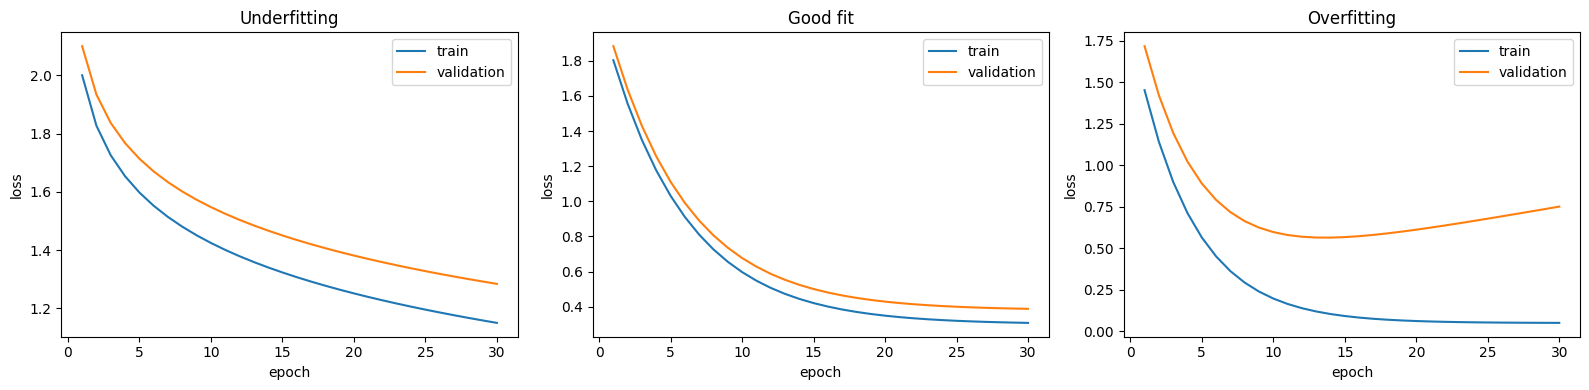

In [12]:
# The three classic learning-curve stories (sketched, not real training runs)
epochs = np.arange(1, 31)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Underfitting: both losses still high, model hasn't captured the pattern
axes[0].plot(epochs, 2.0 - 0.25*np.log(epochs), label='train')
axes[0].plot(epochs, 2.1 - 0.24*np.log(epochs), label='validation')
axes[0].set_title('Underfitting')

# 2. Good fit: both converge, small gap
axes[1].plot(epochs, 1.8*np.exp(-0.18*epochs) + 0.30, label='train')
axes[1].plot(epochs, 1.8*np.exp(-0.18*epochs) + 0.38, label='validation')
axes[1].set_title('Good fit')

# 3. Overfitting: train keeps dropping, validation turns back up
axes[2].plot(epochs, 1.8*np.exp(-0.25*epochs) + 0.05, label='train')
axes[2].plot(epochs, 1.8*np.exp(-0.25*epochs) + 0.30 + 0.015*epochs, label='validation')
axes[2].set_title('Overfitting')

for ax in axes:
    ax.set_xlabel('epoch'); ax.set_ylabel('loss'); ax.legend()
plt.tight_layout()
plt.show()

How to read these stories:

| Shape | Diagnosis | The fix |
|---|---|---|
| Both losses high / still falling at the end | **Underfitting** — the model is too weak or hasn't trained long enough | Train longer, bigger model, higher learning rate |
| Both losses converge with a small gap | **Good fit** — this is what you want | Ship it 🎉 |
| Train loss keeps falling, validation loss turns back *up* | **Overfitting** — the model is memorising the training data | More data, augmentation, early stopping, dropout, regularization (all covered below) |
| Loss is `NaN`, exploding, or bouncing wildly | **Divergence** — usually the learning rate | See the debugging checklist at the end |

Now let's generate a *real* learning curve with our baseline model.

Epoch  1 | train loss: 0.5785 | val loss: 0.3877 | 2.1s
Epoch  2 | train loss: 0.2498 | val loss: 0.3115 | 1.9s
Epoch  3 | train loss: 0.1793 | val loss: 0.2812 | 1.9s
Epoch  4 | train loss: 0.1379 | val loss: 0.2520 | 2.0s
Epoch  5 | train loss: 0.1078 | val loss: 0.2074 | 2.0s
Epoch  6 | train loss: 0.0865 | val loss: 0.2014 | 2.1s
Epoch  7 | train loss: 0.0693 | val loss: 0.1946 | 2.0s
Epoch  8 | train loss: 0.0564 | val loss: 0.2044 | 2.1s


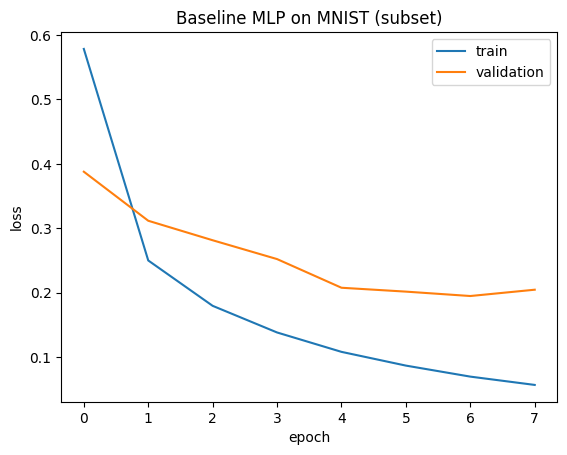

In [13]:
torch.manual_seed(42)
baseline, history = train_model(MLP([500]), train_loader, val_loader, num_epochs=8)

plt.plot(history['train'], label='train')
plt.plot(history['val'], label='validation')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Baseline MLP on MNIST (subset)')
plt.show()

---

# Checkpointing: Pause, Resume, and Watch the Curve Continue

Look at that baseline curve: after 8 epochs the loss was *still falling*. Was 8 enough? On this tiny
model it's cheap to just re-run with more epochs — but real training takes hours or days, and you
don't want to throw all that work away merely to try "a few more epochs" (or because your laptop went
to sleep mid-run).

The answer is a **checkpoint**: a snapshot of everything needed to *resume* training exactly where you
left off —

- the **model** weights (`state_dict`)
- the **optimizer** state — Adam keeps a running average per parameter; if you restart these from
  scratch you'll see a visible *bump* in the loss as it re-finds its footing
- the **epoch** count and the **loss history**, so the curve continues seamlessly

This is the perfect companion to reading loss curves: train a bit, look at the curve, and if it's
still improving, *resume* and watch it keep going — no restart, no lost progress. Let's upgrade our
training function so it can save a checkpoint at the end and, optionally, start from one.

In [14]:
def train_resumable(model, train_loader, val_loader, num_epochs=5, lr=0.001,
                    checkpoint=None, checkpoint_path=None):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # --- resume from a checkpoint if one was given ---
    if checkpoint is not None:
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])   # crucial: restore Adam's state
        history = checkpoint['history']
        start_epoch = checkpoint['epoch']
        print(f'Resuming from epoch {start_epoch}')
    else:
        history = dict(train=[], val=[])
        start_epoch = 0

    for epoch in range(start_epoch, start_epoch + num_epochs):
        model.train()
        train_losses = []
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                val_losses.append(criterion(model(images), labels).item())

        history['train'].append(np.mean(train_losses))
        history['val'].append(np.mean(val_losses))
        print(f"Epoch {epoch+1:2d} | train: {history['train'][-1]:.4f} | val: {history['val'][-1]:.4f}")

    # --- bundle everything needed to resume later, and save it to disk ---
    checkpoint = {
        'epoch': start_epoch + num_epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
    }
    if checkpoint_path:
        torch.save(checkpoint, checkpoint_path)
        print(f'Checkpoint saved to {checkpoint_path}')
    return model, history, checkpoint

In [15]:
# Session 1: train for 5 epochs and save a checkpoint to disk
torch.manual_seed(42)
model, history, ckpt = train_resumable(MLP([500]), train_loader, val_loader,
                                       num_epochs=5, checkpoint_path='mnist_checkpoint.pth')

Epoch  1 | train: 0.5785 | val: 0.3877
Epoch  2 | train: 0.2498 | val: 0.3115
Epoch  3 | train: 0.1793 | val: 0.2812
Epoch  4 | train: 0.1379 | val: 0.2520
Epoch  5 | train: 0.1078 | val: 0.2074
Checkpoint saved to mnist_checkpoint.pth


In [16]:
# Session 2: imagine the process stopped (budget reached, or the machine crashed).
# Load the checkpoint back FROM DISK and continue for 5 more epochs.
ckpt = torch.load('mnist_checkpoint.pth')
model, history, ckpt = train_resumable(MLP([500]), train_loader, val_loader,
                                       num_epochs=5, checkpoint=ckpt,
                                       checkpoint_path='mnist_checkpoint.pth')

Resuming from epoch 5
Epoch  6 | train: 0.0860 | val: 0.2043
Epoch  7 | train: 0.0674 | val: 0.1820
Epoch  8 | train: 0.0525 | val: 0.1813
Epoch  9 | train: 0.0443 | val: 0.1848
Epoch 10 | train: 0.0340 | val: 0.1759
Checkpoint saved to mnist_checkpoint.pth


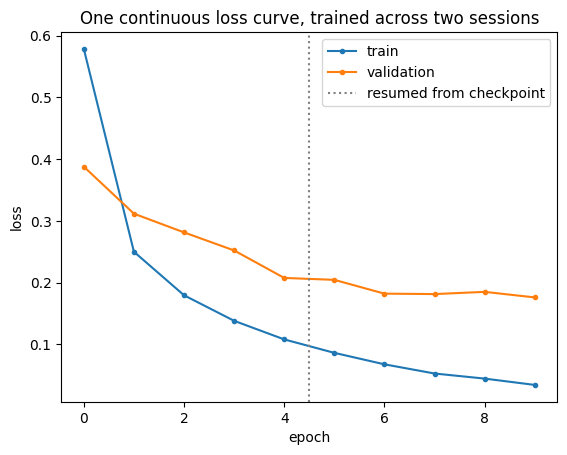

In [17]:
# The history spans all 10 epochs - and the resumed half picks up right where the first left off,
# with no discontinuity. That smoothness is the optimizer state being restored correctly.
resumed_at = 5
plt.plot(history['train'], marker='o', ms=3, label='train')
plt.plot(history['val'], marker='o', ms=3, label='validation')
plt.axvline(resumed_at - 0.5, color='gray', linestyle=':', label='resumed from checkpoint')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend()
plt.title('One continuous loss curve, trained across two sessions')
plt.show()

---

# Navigating Hyperparameter Space

**Parameters** (weights, biases) are learned by the network. **Hyperparameters** are the knobs *you*
choose: learning rate, batch size, number of layers, neurons per layer, optimiser, dropout rate...
Each combination is a point in "hyperparameter space", and our job is to find a good one — methodically.

## Hyperparameter #1: The Learning Rate

The learning rate is the single most important hyperparameter. It controls the size of the step we
take down the loss landscape on every update:

- **too high** → we leap over the valley and the loss oscillates or explodes
- **too low** → we crawl, and training takes forever (or stalls in a poor spot)
- **just right** → fast, stable descent

Let's run the experiment instead of taking this on faith. We train the *same* model with four
learning rates spanning five orders of magnitude:

In [18]:
histories = {}
for lr in [1.0, 0.1, 0.001, 0.00001]:
    print(f'--- learning rate = {lr} ---')
    torch.manual_seed(42)
    _, hist = train_model(MLP([128]), train_loader, val_loader, num_epochs=5, lr=lr, verbose=False)
    histories[lr] = hist
    print(f'final val loss: {hist["val"][-1]:.4f}')

--- learning rate = 1.0 ---
final val loss: 2.3067
--- learning rate = 0.1 ---
final val loss: 0.8283
--- learning rate = 0.001 ---
final val loss: 0.3305
--- learning rate = 1e-05 ---
final val loss: 1.9398


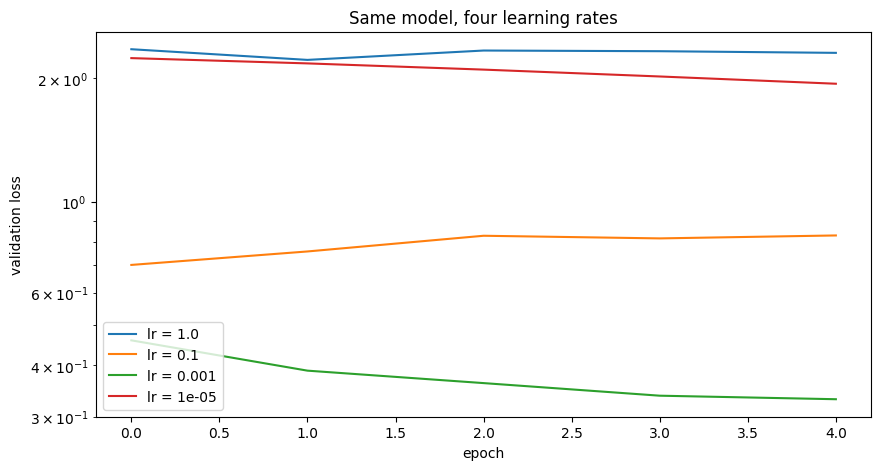

In [19]:
plt.figure(figsize=(10, 5))
for lr, hist in histories.items():
    plt.plot(hist['val'], label=f'lr = {lr}')
plt.xlabel('epoch'); plt.ylabel('validation loss')
plt.title('Same model, four learning rates')
plt.legend(); plt.yscale('log')
plt.show()

Typical result: `1.0` bounces around or diverges, `0.00001` barely moves, and something around
`0.001`–`0.1` wins. A good strategy in practice:

1. Start from a sensible default (`1e-3` for Adam, `1e-2`–`1e-1` for SGD)
2. Sweep in powers of 10 to find the right *order of magnitude*
3. Fine-tune within that decade if needed
4. For long runs, use a **learning rate scheduler** (e.g. `torch.optim.lr_scheduler.StepLR`) to
   decay the rate as training progresses — big steps early, small steps to settle in

## Hyperparameter #2: Capacity (Width & Depth)

Capacity is the model's ability to represent complex patterns. Too little → underfitting.
Too much → overfitting (and wasted compute). Let's compare a tiny, a medium and a deep model:

tiny  [8]: final val loss 0.4560
medium [500]: final val loss 0.2044
deep  [512,256,128]: final val loss 0.1755


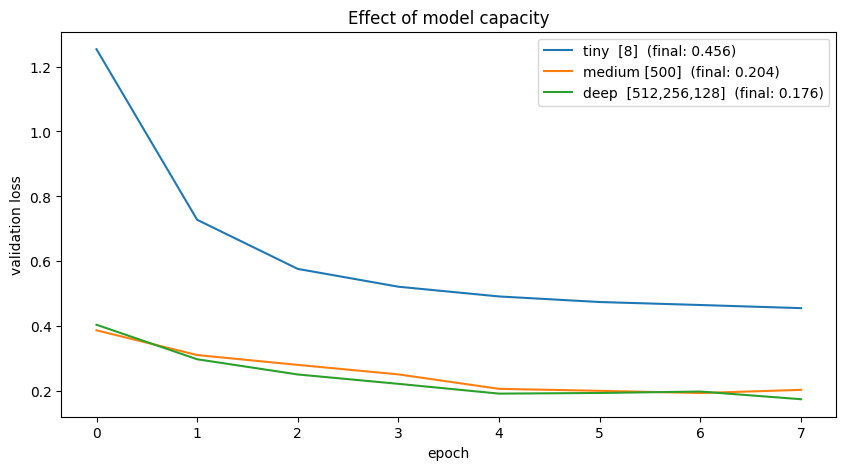

In [20]:
capacity_experiments = {
    'tiny  [8]':            [8],
    'medium [500]':         [500],
    'deep  [512,256,128]':  [512, 256, 128],
}

plt.figure(figsize=(10, 5))
for name, hidden in capacity_experiments.items():
    torch.manual_seed(42)
    _, hist = train_model(MLP(hidden), train_loader, val_loader, num_epochs=8, verbose=False)
    plt.plot(hist['val'], label=f'{name}  (final: {hist["val"][-1]:.3f})')
    print(f'{name}: final val loss {hist["val"][-1]:.4f}')
plt.xlabel('epoch'); plt.ylabel('validation loss'); plt.legend()
plt.title('Effect of model capacity')
plt.show()

## Hyperparameter #3: Batch Size

The batch size controls how many samples we average over before each weight update:

- **batch size = 1** → *stochastic* gradient descent: noisy, slow per-epoch, but the noise can help escape bad spots
- **batch size = whole dataset** → *batch* gradient descent: smooth but memory-hungry and each step is expensive
- **in between** → *mini-batch* gradient descent: the standard choice (32–256 is typical)

Larger batches give more stable gradients and better GPU utilisation, but *too* large can generalise
worse and may need a higher learning rate to compensate. Try `make_loaders(batch_size=8)` vs
`make_loaders(batch_size=1024)` yourself and compare both the loss curves *and* the wall-clock time
per epoch.

---


# Model Improvement Techniques

To be able to diagnose your model, you first need to understand learning curves. [This article](https://machinelearningmastery.com/learning-curves-for-diagnosing-machine-learning-model-performance/) explains some common learning curves and what they represent.

## Tackling Overfitting
To deal with overfitting, there are various techniques that can be used. Let’s explore some of them.

### 1. Data Augmentation
This involved creating more data from existing data, e.g. for images (where symmetry doesn't matter), flipping the images to get new ones, or rotating them. This may not be appropriate in some cases, e.g. horizontal flipping 'b' vs 'd', or in MNIST - rotating them, coz of 6 vs 9.

### 2. Early stopping
Before the model overfits, the training loss is going down, and the validation is also going down. When the validation loss keeps rising, the model is overfitting. It hence makes sense to stop before this happens. Different criteria can be used to determine the stoppage point and store that model and not the one that comes later.

### 3. Dropout
Dropout refers to dropping out units in a neural network. By dropping a unit out, it means to remove it temporarily from the network. The choice of which units to drop is random. Each unit is retained with a fixed probability p independent of other units.

This procedure effectively generates slightly different models with different neuron topologies at each iteration, thus giving neurons in the model, less chance to coordinate in the memorisation process that happens during overfitting. Thus making it better at generalization and cope with overfitting issue.

![dropout](dropout.webp)

> *Illustrative snippet — read, don't run (it references names defined elsewhere):*

```python
self.dropout = nn.Dropout(0.2) # generally a good value of dropout is between 0.2 and 0.5
```

Some tips on using Dropout:

- Generally, use a small dropout value of 20%-50% of neurons, with 20% providing a good starting point. A probability too low has minimal effect, and a value too high results in under-learning by the network.
- Use a larger network. You are likely to get better performance when Dropout is used on a larger network, giving the model more of an opportunity to learn independent representations.
- Use Dropout on incoming (visible) as well as hidden units. Application of Dropout at each layer of the network has shown good results.
- Use a large learning rate with decay and a large momentum. Increase your learning rate by a factor of 10 to 100 and use a high momentum value of 0.9 or 0.99.
- Constrain the size of network weights. A large learning rate can result in very large network weights.

### 4. Regularization
**L1 regularization( Lasso Regression)**

It adds sum of the absolute values of all weights in the model to cost function. 

It shrinks the less important feature’s coefficient to zero thus, removing some feature and hence providing a sparse solution

![L1](l1_reg.webp)

> *Illustrative snippet — read, don't run (it references names defined elsewhere):*

```python
l1_penalty = nn.L1Loss(size_average=False)
reg_loss = 0

for param in model.parameters():
    reg_loss += l1_penalty(param)

factor = const_val #lambda
loss += factor * reg_loss
```

Both of these regularizations are scaled by a (small) factor lambda (to control importance of regularization term).

**L2 regularization( Ridge Regression)**

It adds sum of squares of all weights in the model to cost function. 

It is able to learn complex data patterns and gives non-sparse solutions unlike L1 regularization.

> *Illustrative snippet — read, don't run (it references names defined elsewhere):*

```python
#easiest way to add L2 regularization
#is to add the L2 penalty to the loss function
#in the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
```

### Early Stopping — Implemented

The idea was described above; here is a working implementation. We keep a copy of the best model
seen so far (by validation loss), and stop when there has been no improvement for `patience` epochs.
This pattern appears, in some form, in virtually every serious training script.

Epoch  1 | train: 0.5785 | val: 0.3877
Epoch  2 | train: 0.2498 | val: 0.3115
Epoch  3 | train: 0.1793 | val: 0.2812
Epoch  4 | train: 0.1379 | val: 0.2520
Epoch  5 | train: 0.1078 | val: 0.2074
Epoch  6 | train: 0.0865 | val: 0.2014
Epoch  7 | train: 0.0693 | val: 0.1946
Epoch  8 | train: 0.0564 | val: 0.2044
Epoch  9 | train: 0.0426 | val: 0.1830
Epoch 10 | train: 0.0348 | val: 0.1734
Epoch 11 | train: 0.0277 | val: 0.1770
Epoch 12 | train: 0.0226 | val: 0.1783
Epoch 13 | train: 0.0165 | val: 0.1791
Stopping early at epoch 13 — no improvement for 3 epochs.


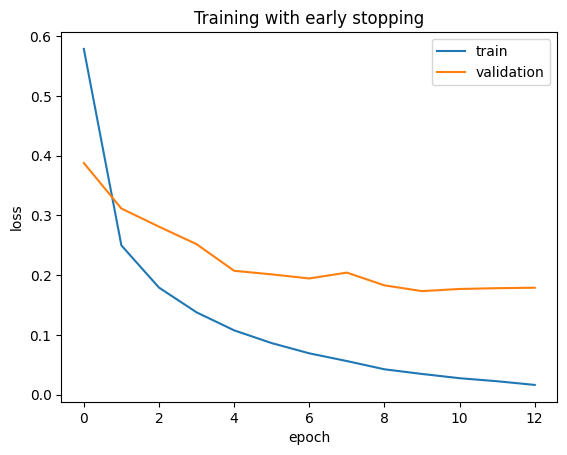

In [21]:
def train_with_early_stopping(model, train_loader, val_loader, max_epochs=50,
                              lr=0.001, patience=3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = dict(train=[], val=[])
    best_val = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()
        train_losses = []
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                val_losses.append(criterion(model(images), labels).item())

        history['train'].append(np.mean(train_losses))
        history['val'].append(np.mean(val_losses))
        print(f"Epoch {epoch+1:2d} | train: {history['train'][-1]:.4f} | val: {history['val'][-1]:.4f}")

        # --- the early stopping logic ---
        if history['val'][-1] < best_val:
            best_val = history['val'][-1]
            best_state = copy.deepcopy(model.state_dict())   # remember the best model
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f'Stopping early at epoch {epoch+1} — no improvement for {patience} epochs.')
                break

    model.load_state_dict(best_state)   # roll back to the best version
    return model.eval(), history

torch.manual_seed(42)
model_es, history_es = train_with_early_stopping(MLP([500]), train_loader, val_loader,
                                                 max_epochs=30, patience=3)

plt.plot(history_es['train'], label='train')
plt.plot(history_es['val'], label='validation')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Training with early stopping')
plt.show()

### Data Augmentation — Implemented

For images, `torchvision.transforms` makes augmentation a one-liner. Each epoch the model sees a
*slightly different* version of every image, which makes memorising the training set much harder.
(Remember the caveat from above: for MNIST we keep rotations small — a heavily rotated 6 becomes a 9!)

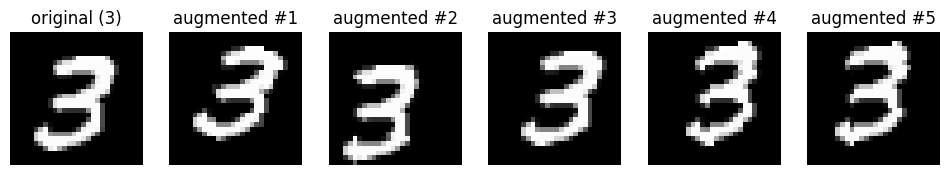

In [22]:
augment = transforms.Compose([
    transforms.RandomRotation(10),                       # rotate up to ±10 degrees
    transforms.RandomAffine(0, translate=(0.1, 0.1)),    # shift up to 10%
    transforms.ToTensor(),
])

# the same digit, augmented five different ways
raw_dataset = torchvision.datasets.MNIST(root='./data', train=True)   # no transform -> PIL images
img, label = raw_dataset[7]

fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
axes[0].imshow(img, cmap='gray'); axes[0].set_title(f'original ({label})')
for i in range(1, 6):
    axes[i].imshow(augment(img).squeeze(), cmap='gray'); axes[i].set_title(f'augmented #{i}')
for ax in axes:
    ax.axis('off')
plt.show()

# To use it in training, simply pass `transform=augment` when creating the *training* dataset.
# (Never augment the validation/test set — we want to measure performance on real data!)

## Weight Initialization

This is how the weights of the networks are initialized. Bias values can be (and often are) initialized to zero. 

But weights cannot be initialized to zero because if they are, they will all be updated the same way and the model won't be able to learn.

At the same time, just using normal distribution for the random initialization of the weights cause problems with the network. 
That's why, sometimes we need a more advanced approach.

Let's start by looking at the default Pytorch Weight Initialisation.

Typically (for Linear and Convolution layers):

- Weights: Uniform distribution bounded by ±1​.
- Biases: Initialized to zeros.

In [23]:
import torch
import torch.nn as nn

# Define a simple Linear layer
model = nn.Linear(10, 5)  # Input features: 10, Output features: 5

# Inspect the weights
print("Default Weight Initialization:")
print(model.weight)

# Inspect the biases
print("Default Bias Initialization:")
print(model.bias)

Default Weight Initialization:
Parameter containing:
tensor([[ 0.2180,  0.0325,  0.0209, -0.0420,  0.0944, -0.0833,  0.0736, -0.1162,
         -0.2840, -0.0247],
        [ 0.1286, -0.2230, -0.2389,  0.1984,  0.2275,  0.2192,  0.2436, -0.2116,
          0.2561, -0.0366],
        [ 0.1882,  0.0223, -0.2906, -0.0935,  0.2092,  0.2329, -0.0338, -0.2777,
          0.1035,  0.0621],
        [ 0.0749, -0.0589,  0.0579,  0.1862,  0.3154,  0.2227, -0.0343,  0.0230,
          0.1320, -0.0596],
        [ 0.0033,  0.1651, -0.2678,  0.2017,  0.0282, -0.3008,  0.0756, -0.1390,
         -0.1453, -0.1946]], requires_grad=True)
Default Bias Initialization:
Parameter containing:
tensor([ 0.1031, -0.2748, -0.1818, -0.2486, -0.1785], requires_grad=True)


The default initialization works well for shallow networks, but as your models grow deeper or more complex, these defaults might not suffice.

Let's look at some other initializations you can use.

**Xavier Initialization (Glorot Initialization)**

Xavier Initialization is like Goldilocks for weights: not too big, not too small — just right.

Xavier initialization works best for layers with linear activations or sigmoid functions. It ensures that the variance of activations is maintained across layers.


In [24]:
import torch
import torch.nn as nn
import torch.nn.init as init #needed for custom weight initialization

# Define a simple Linear layer
model = nn.Linear(10, 5)

# Apply Xavier Uniform Initialization
init.xavier_uniform_(model.weight)

# Check the initialized weights
print("Xavier Uniform Initialization:")
print(model.weight)

Xavier Uniform Initialization:
Parameter containing:
tensor([[-0.1975,  0.4548, -0.1816, -0.6310, -0.1893,  0.0220, -0.5797,  0.6020,
         -0.3947, -0.2064],
        [ 0.6002,  0.3605, -0.5178,  0.2849,  0.2382, -0.0619,  0.2753,  0.2726,
         -0.1552, -0.1075],
        [-0.4560,  0.3133,  0.2172,  0.2396, -0.5026,  0.2388, -0.6082,  0.0863,
         -0.3096, -0.3136],
        [ 0.2941,  0.0306,  0.3489, -0.6248,  0.0108,  0.1915, -0.3088, -0.3792,
         -0.0093,  0.2816],
        [ 0.5946, -0.4179,  0.3477, -0.4129,  0.5906,  0.5736, -0.6252, -0.0552,
         -0.3020, -0.1153]], requires_grad=True)


**He Initialization (Kaiming Initialization)**

He Initialization is perfect for layers with ReLU or variants of ReLU activations.

It’s designed to address vanishing gradients by maintaining the variance of gradients during backpropagation.


In [25]:
# Apply He Normal Initialization
init.kaiming_normal_(model.weight, mode='fan_in', nonlinearity='relu')

# Check the initialized weights
print("He Normal Initialization:")
print(model.weight)

He Normal Initialization:
Parameter containing:
tensor([[-0.1124,  0.2375,  0.1844, -0.3360, -0.2816,  0.4776, -0.3689,  0.5602,
          0.1109, -0.6693],
        [ 0.3629, -0.4853, -0.3511, -0.1287, -0.0436, -0.2583,  0.6893, -0.4363,
          0.5272, -1.2254],
        [-0.5330,  0.2315,  0.1668, -0.1280,  0.1449,  0.5358, -0.2516, -0.1653,
          0.3118, -0.0663],
        [-0.3563, -0.9979, -0.0371, -0.5694, -0.4672, -0.6683,  0.0576,  0.1492,
          0.5127,  0.0662],
        [-0.1584,  0.1388, -0.2240,  0.3958, -0.5171, -0.5886, -0.5223,  0.0602,
          0.6370, -0.2885]], requires_grad=True)


**Orthogonal Initialization**

Orthogonal weights can work wonders for stability in RNNs or deep architectures.

Orthogonal initialization ensures that weight matrices are orthogonal, which can help maintain variance during deep computations.

In [26]:
# Apply Orthogonal Initialization
init.orthogonal_(model.weight)

# Check the initialized weights
print("Orthogonal Initialization:")
print(model.weight)

Orthogonal Initialization:
Parameter containing:
tensor([[ 0.0604, -0.1985, -0.0099, -0.7127, -0.2673,  0.1272,  0.5990, -0.0330,
         -0.0111,  0.0365],
        [ 0.7462,  0.2621,  0.2221,  0.0037, -0.1097, -0.3599,  0.0490, -0.3077,
          0.1010, -0.2763],
        [ 0.4378, -0.3998, -0.2916,  0.4707, -0.2647,  0.1200,  0.2440,  0.3588,
          0.1438,  0.2201],
        [ 0.1544, -0.0022, -0.3857, -0.2511,  0.5333, -0.5593,  0.0323,  0.2802,
         -0.1405,  0.2604],
        [ 0.4107,  0.2104,  0.1452, -0.2812,  0.2242,  0.5795, -0.3036,  0.4449,
         -0.1029, -0.0090]], requires_grad=True)


**Tip # 1: Visualize the weights**

Use a histogram to inspect the distribution of your model’s weights. This can help you detect issues like weights being too concentrated in a narrow range or skewed to one side.

If your weights are not distributed as expected (e.g., too many zeros or extreme values), it could lead to issues like poor gradient flow or slow training.

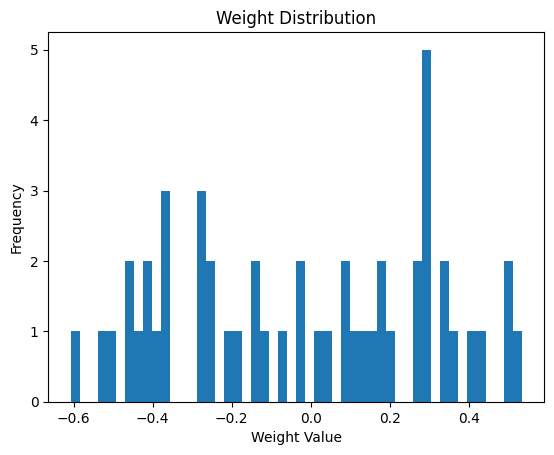

In [27]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Define a Linear layer and initialize weights
model = nn.Linear(10, 5)
nn.init.xavier_uniform_(model.weight)

# Convert weights to a NumPy array
weights = model.weight.detach().numpy()

# Visualize the weight distribution
plt.hist(weights.flatten(), bins=50)
plt.title("Weight Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.show()

**Tip 2 Monitoring Gradients During Training**

Even if your weights look good, what happens during backpropagation might tell a different story.

Check the gradients of your model parameters during training. Large or vanishing gradients can indicate initialization problems.

In [28]:
# Example: Print gradients during training
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Layer: {name}, Gradient: {param.grad}")

Layer: weight, Gradient: None
Layer: bias, Gradient: None


### Other Initialization Considerations

**Initialize Biases**

While PyTorch initializes biases to zero by default, you can set custom values to give your model an edge. For example, initializing biases to a small positive constant can help avoid dead neurons in ReLU layers.

In [29]:
import torch.nn.init as init

# Define a bias initialization function
def init_biases(m):
    if hasattr(m, 'bias') and m.bias is not None:
        init.constant_(m.bias, 0.1)

# Apply the function to all layers
model.apply(init_biases)

# Verify the initialized biases
for name, param in model.named_parameters():
    if 'bias' in name:
        print(f"{name} initialized to {param}")

bias initialized to Parameter containing:
tensor([0.1000, 0.1000, 0.1000, 0.1000, 0.1000], requires_grad=True)


**RNNs (and LSTMs)**

Initialization for RNNs often involves setting weights for input-to-hidden and hidden-to-hidden connections separately.

In [30]:
rnn = nn.LSTM(input_size=10, hidden_size=20, num_layers=2)

for name, param in rnn.named_parameters():
    if 'weight_ih' in name:  # Input-to-hidden weights
        nn.init.xavier_uniform_(param)
    elif 'weight_hh' in name:  # Hidden-to-hidden weights
        nn.init.orthogonal_(param)

---

# When Your Model Refuses to Converge: A Debugging Checklist

Sooner or later (probably this week!) you will stare at a loss that won't go down, is `NaN`, or
bounces around randomly. Work through this list **in order** — the boring early items catch the
majority of real-world bugs:

1. **Look at your data.** Plot a batch of inputs with their labels. Are images black? Labels shuffled
   relative to inputs? Features unnormalised (one column in the thousands, another in 0–1)?
   Data bugs cause more "convergence" problems than any model issue.
2. **Check shapes and the loss function contract.** `CrossEntropyLoss` wants raw logits and integer
   class labels; `BCELoss` wants probabilities. Silent shape broadcasting (e.g. `(N,1)` vs `(N,)`)
   can produce a loss that *runs* but learns nothing.
3. **Can you overfit a single batch?** Take 32 samples and train on only those for 200 steps. A
   correct model should reach ~zero loss. If it can't memorise 32 examples, the bug is in the
   model/loss wiring, not the hyperparameters.
4. **Loss is NaN or exploding** → learning rate too high, or exploding gradients. Lower the LR by
   10–100×; for recurrent networks add gradient clipping
   (`torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)`).
5. **Loss flat from the start** → learning rate too low, dead ReLUs, or vanishing gradients from a
   bad initialization (see the weight-initialization section above). Monitor the gradient norms —
   if they are ~0 in early layers, the signal isn't reaching them.
6. **Forgot `optimizer.zero_grad()`?** Gradients *accumulate* in PyTorch — forgetting to zero them
   is a classic.
7. **Train good, validation bad** → that's not a convergence bug, that's overfitting. Use the
   toolbox from this notebook.
8. **Change one thing at a time.** Fix the random seed, run controlled experiments, keep notes.
   Tuning is science, not alchemy.

# Other Tips

Hyperparameters:
- **Number of hidden layers**: The more hidden layers you have, the deeper your network is going to be. Generally, *having more layers will help your network more* than increasing the number of neurons in the hidden layers.
- **Number of neurons in the hidden layers**: Each hidden layer can have *a different number* of neurons. This value needs to be adjusted based on how the network is performing.
- **Activation function**: Each layer has its own activation function except the input layer. The activation function of the hidden layers cannot be linear.
- **Batch size**: Batch size is the amount of data points you put in each batch while training your network. If you use a batch size of 1, you will be doing Stochastic gradient descent (GD). If you use batch size equals the number of data points in your whole dataset, that is Batch GD. If batch size is anything between 2 to number of data points in your whole dataset, you are doing mini-batch gradient-descent.
- **Regularization**: L1 and L2 regularization has a hp called alpha, and dropout has a hp called the dropout rate. Vary them to optimise your model.



### **My network is taking too long to train! What can I do?**

Techniques to speed up training:
- Applying good initialization
- Using a good activation function
- Using batch normalization
- Reusing parts of a pretained network
- Normalizing the data
- Using mini-batches
- Learning rate scheduling
- A faster optimization algorithm
- Pruning the network

Some I didn't get to cover, but please look them up when you get the chance.



### **The results are different on my machine than on theirs**

Ensure reproducibility by setting a random seed.

Only the first one is necessary, but to be safe (in case you initialise the other important stuff as random variables from other sources), set the following at the beginning of your notebook.


In [31]:
import torch
import random
import numpy as np

# Define the seed value
SEED = 42

# Set seed for PyTorch
torch.manual_seed(SEED)

# Set seed for CUDA (if using GPUs)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups

# Set seed for Python's random module
random.seed(SEED)

# Set seed for NumPy
np.random.seed(SEED)

# Ensure deterministic behavior for PyTorch operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

---

# Day 2 Recap & Exercises

**What you learned today:** how to record and read learning curves, checkpointing to pause and resume
training, how learning rate / capacity / batch size shape training, the overfitting toolbox
(augmentation, early stopping, dropout, regularization), weight initialization, and a systematic
debugging method.

### Exercises

1. **Batch size sweep.** Using `make_loaders(batch_size=...)`, compare batch sizes 8, 100 and 1024.
   Plot validation curves *and* note the time per epoch. Which would you pick, and why?
2. **Dropout in practice.** Add `nn.Dropout(0.3)` after each hidden layer of the `MLP` class, then
   train a deliberately oversized model (`MLP([1024, 1024])`) with and without dropout for 15 epochs.
   Compare the gap between train and validation loss.
3. **Combine the toolbox.** Train the best MNIST model you can on today's *small* training subset —
   augmentation, early stopping, dropout, weight decay, your choice of architecture. Evaluate on the
   full test set. Class competition: highest test accuracy wins.
4. **Sabotage & rescue (pairs).** Secretly break your partner's training script in one way (huge LR,
   missing `zero_grad`, shuffled labels, sigmoid + 10 layers...). Swap laptops and use the debugging
   checklist to find the bug.
5. **Prove the optimizer state matters.** Modify `train_resumable` to throw away the optimizer state
   on resume (skip `optimizer.load_state_dict(...)`). Train 5 + 5 epochs and plot the curve — can you
   see the bump at the resume point? That's why we save more than just the weights.

### Tomorrow: Day 3

So far our networks see images as a flat list of 784 numbers — throwing away *where* each pixel is.
Tomorrow we meet **Convolutional Neural Networks**, which don't just process pixels; they understand
them.